In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import seaborn as sns

In [1]:
df_actividades =pd.read_csv("../data/clean/df_actividades_geo.csv")



NameError: name 'pd' is not defined

In [3]:
# Configuración de Parametros

TOP_N = 10
PALETA_HEAT = "YlGnBu"

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
sns.set_context("notebook")

# Revision de Dataset

In [4]:
# Parametros
TOP_N = 10
PALETA_HEAT = "YlGnBu"

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
sns.set_context("notebook")

In [5]:
# Normalizar nombres de columnas
df_actividades.columns = (
    df_actividades.columns
      .str.strip()
      .str.lower()
      .str.replace(r"\s+", "_", regex=True)
      .str.replace("-", "_")
)

# Columnas esperadas (ajusta si tu csv difiere)
cols_obligatorias = [
    "mes","categoria","producto","subcategoria",
    "comunidad_autonoma","provincia",
    "gasto_total_promedio","precio_medio_entrada_promedio",
    "valoracion_por_categoria_promedio","valoracion_general_promedio",
    "total_opiniones_categoria_promedio",
    "hay_valoracion"
]

faltantes = [c for c in cols_obligatorias if c not in df_actividades.columns]
if faltantes:
    print("⚠️ Faltan columnas:", faltantes)

df_actividades.head()


,mes,categoria,producto,subcategoria,comunidad_autonoma,provincia,gasto_total_promedio,precio_medio_entrada_promedio,valoracion_por_categoria_promedio,valoracion_general_promedio,total_opiniones_categoria_promedio,hay_valoracion,lat_provincia,lng_provincia
0,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,almeria,4123.00,87.50,4.32,4.19,23376.0,True,37.151750,-2.413226
1,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cadiz,95390.25,2151.75,4.27,4.26,12349.5,True,36.581088,-5.730183
2,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cordoba,147685.50,1044.50,4.32,4.29,3767.0,True,37.902717,-4.736894
3,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,granada,67115.00,601.67,4.52,4.37,18491.5,True,37.179351,-3.431469
4,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,huelva,25675.00,499.00,4.12,4.11,8395.5,True,37.631104,-6.785624


In [6]:
# -----------------------------
# 1.1) Perfilado rápido
# -----------------------------
print("Filas / Columnas:", df_actividades.shape)
display(df_actividades.info())
display(df_actividades.describe(include="all").T.head(25))

# Nulos por columna
nulos = df_actividades.isna().sum().sort_values(ascending=False)
display(nulos)

# Duplicados completos
print("Duplicados completos:", df_actividades.duplicated().sum())

# Duplicados por llave natural (ajusta si tu grano cambia)
key = ["mes","producto","subcategoria","comunidad_autonoma","provincia","categoria"]
dup_key = df_actividades.duplicated(subset=key).sum()
print("Duplicados por llave (key):", dup_key)


Filas / Columnas: (3609, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3609 entries, 0 to 3608
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   mes                                 3609 non-null   int64  
 1   categoria                           3609 non-null   object 
 2   producto                            3609 non-null   object 
 3   subcategoria                        3609 non-null   object 
 4   comunidad_autonoma                  3609 non-null   object 
 5   provincia                           3609 non-null   object 
 6   gasto_total_promedio                3609 non-null   float64
 7   precio_medio_entrada_promedio       3609 non-null   float64
 8   valoracion_por_categoria_promedio   3567 non-null   float64
 9   valoracion_general_promedio         3567 non-null   float64
 10  total_opiniones_categoria_promedio  3567 non-null   float64
 11  hay_valoracion

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mes,3609.0,NaN,NaN,NaN,6.730396,3.437544,1.0,4.0,7.0,10.0,12.0
categoria,3609,7,vida nocturna,1179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
producto,3609,2,espectaculos,2203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subcategoria,3609,12,musica,607,NaN,NaN,NaN,NaN,NaN,NaN,NaN
comunidad_autonoma,3609,18,andalucia,618,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provincia,3609,51,barcelona,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gasto_total_promedio,3609.0,NaN,NaN,NaN,178811.90749,341642.44816,49.0,13024.0,63827.0,196873.9,5578091.0
precio_medio_entrada_promedio,3609.0,NaN,NaN,NaN,1335.388523,1890.121841,25.0,531.69,952.0,1453.71,47799.0
valoracion_por_categoria_promedio,3567.0,NaN,NaN,NaN,4.183793,0.319747,1.93,4.015,4.23,4.37,5.0
valoracion_general_promedio,3567.0,NaN,NaN,NaN,4.239313,0.100118,3.97,4.17,4.25,4.31,4.43


valoracion_por_categoria_promedio     42
valoracion_general_promedio           42
total_opiniones_categoria_promedio    42
lat_provincia                         23
lng_provincia                         23
mes                                    0
provincia                              0
comunidad_autonoma                     0
subcategoria                           0
producto                               0
categoria                              0
precio_medio_entrada_promedio          0
gasto_total_promedio                   0
hay_valoracion                         0
dtype: int64

Duplicados completos: 0
Duplicados por llave (key): 0


In [7]:
# -----------------------------
# 1.2) Limpieza ligera de strings
# -----------------------------
for c in ["categoria","producto","subcategoria","comunidad_autonoma","provincia"]:
    if c in df_actividades.columns:
        df_actividades[c] = (df_actividades[c].astype(str).str.strip()
                         .str.lower()
                         .str.replace(r"\s+", " ", regex=True))


# Distribución y rango de costes (base para estimación)

In [8]:
# -----------------------------
# 2) Distribución de variables económicas
# -----------------------------
cols_coste = ["gasto_total_promedio","precio_medio_entrada_promedio"]

df_actividades[cols_coste].describe().T


,count,mean,std,min,25%,50%,75%,max
gasto_total_promedio,3609.0,178811.907490,341642.448160,49.0,13024.00,63827.0,196873.90,5578091.0
precio_medio_entrada_promedio,3609.0,1335.388523,1890.121841,25.0,531.69,952.0,1453.71,47799.0


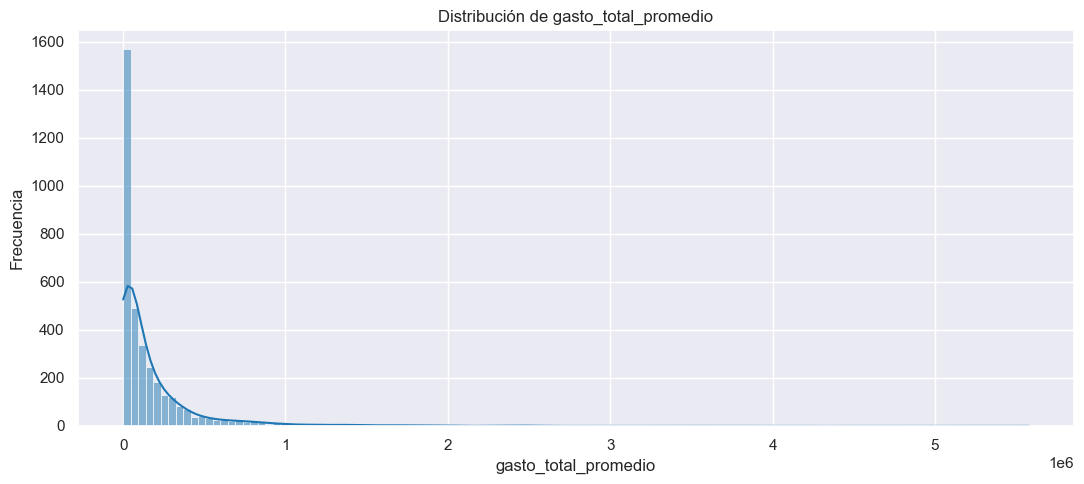

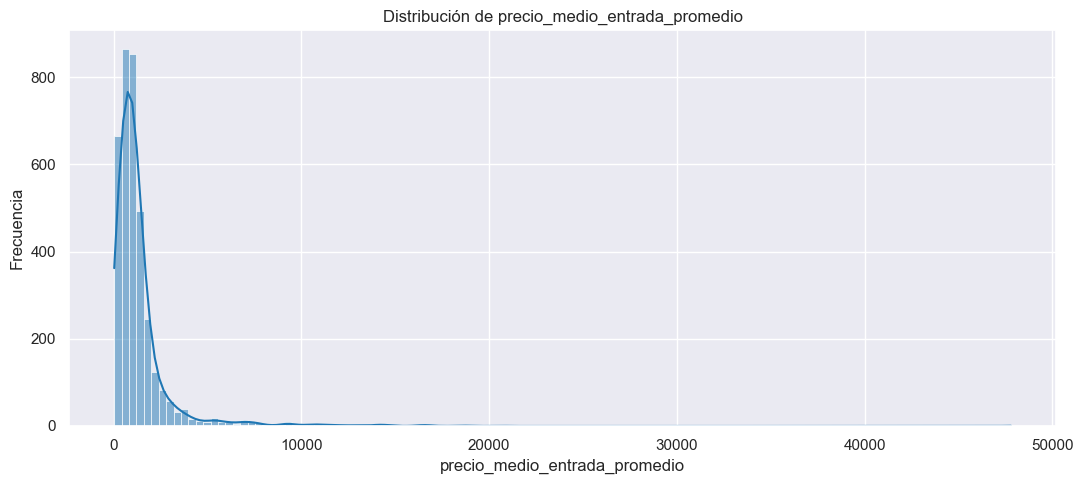

In [9]:
# Histogramas + KDE
for col in cols_coste:
    plt.figure()
    sns.histplot(df_actividades[col].dropna(), kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


Gasto total promedio : La distribución está fuertemente sesgada a la derecha.
Un pequeño número de combinaciones (mes–provincia–actividad) concentra volúmenes de gasto extremadamente altos, mientras que la mayoría tiene gastos mucho más moderados.
También hay asimetría fuerte, pero menos extrema que el gasto total.
La mayoría de actividades se mueve entre 500 y 1,500, pero existen actividades premium o agregadas con precios muy altos
El análisis descriptivo evidencia una fuerte heterogeneidad en los costes de las actividades turísticas, lo que justifica el uso de métricas robustas (medianas y percentiles) para la estimación de presupuestos. Esta aproximación permite al sistema CulturaTrip generar recomendaciones realistas y adaptadas al perfil económico del viajero, evitando sesgos derivados de valores extremos
Dada la fuerte asimetría observada en las variables económicas, se descartó el uso de la media como estimador principal de coste, priorizando métricas robustas como la mediana y los percentiles, con el fin de evitar sesgos derivados de valores extremos.

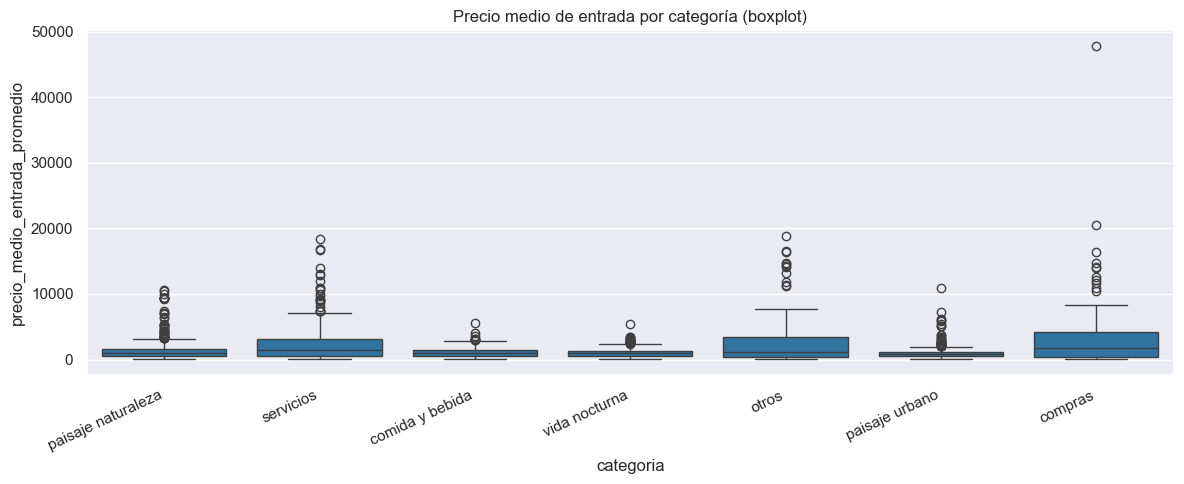

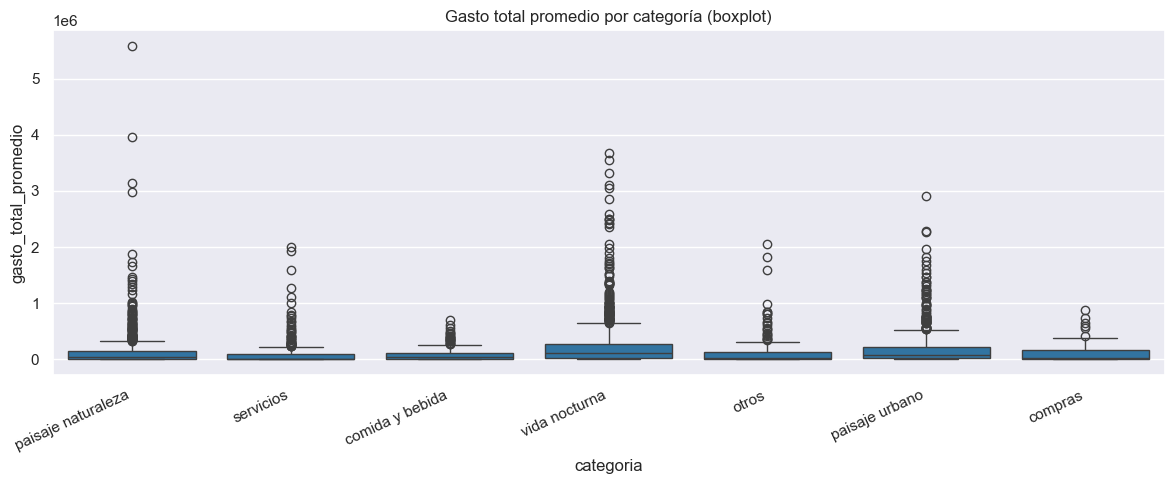

In [10]:
# Boxplot por categoría (coste)
plt.figure(figsize=(12,5))
sns.boxplot(data=df_actividades, x="categoria", y="precio_medio_entrada_promedio")
plt.title("Precio medio de entrada por categoría (boxplot)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(data=df_actividades, x="categoria", y="gasto_total_promedio")
plt.title("Gasto total promedio por categoría (boxplot)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


El precio medio depende fuertemente de la categoría, y algunas presentan una variabilidad extrema que invalida el uso de la media como métrica representativa.
El análisis por categoría revela una fuerte heterogeneidad en los precios, especialmente en las categorías de compras y servicios, lo que justifica la aplicación de estimadores robustos y reglas de segmentación específicas por tipo de actividad.
Precio alto no implica necesariamente mayor impacto económico agregado.
Las categorías con mayor gasto total no coinciden necesariamente con las de mayor precio medio, evidenciando que el impacto económico turístico está más relacionado con el volumen de participación que con el coste individual de las actividades.


# # Ranking territorial (CCAA y provincias)

In [11]:
# -----------------------------
# 3) Agregaciones por región
# -----------------------------
metricas = {
    "gasto_total_promedio": "sum",           # volumen total
    "precio_medio_entrada_promedio": "mean", # nivel de precio
    "valoracion_por_categoria_promedio": "mean",
    "valoracion_general_promedio": "mean",
    "total_opiniones_categoria_promedio": "sum"
}

agg_com = (df_actividades.groupby("comunidad_autonoma", as_index=False)
             .agg(metricas)
             .rename(columns={
                 "gasto_total_promedio": "gasto_total",
                 "precio_medio_entrada_promedio": "precio_medio",
                 "valoracion_por_categoria_promedio": "valoracion_categoria_media",
                 "valoracion_general_promedio": "valoracion_general_media",
                 "total_opiniones_categoria_promedio": "total_opiniones"
             }))

agg_prov = (df_actividades.groupby(["comunidad_autonoma","provincia"], as_index=False)
              .agg(metricas)
              .rename(columns={
                 "gasto_total_promedio": "gasto_total",
                 "precio_medio_entrada_promedio": "precio_medio",
                 "valoracion_por_categoria_promedio": "valoracion_categoria_media",
                 "valoracion_general_promedio": "valoracion_general_media",
                 "total_opiniones_categoria_promedio": "total_opiniones"
              }))

display(agg_com.head())
display(agg_prov.head())


,comunidad_autonoma,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,andalucia,1.152496e+08,1174.503625,4.279806,4.312071,2.139871e+07
1,aragon,4.961187e+07,1194.717641,4.126872,4.230923,1.417059e+06
2,canarias,2.492946e+07,882.092487,4.153147,4.270660,1.654817e+07
3,cantabria,5.713838e+06,1080.807963,4.187222,4.270000,9.700400e+05
4,castilla y leon,6.364174e+07,1119.311290,4.150075,4.147368,2.233137e+06


,comunidad_autonoma,provincia,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,andalucia,almeria,16586324.96,1090.640769,4.065000,4.19,824651.0
1,andalucia,cadiz,10367558.87,1388.662073,4.312683,4.26,405379.5
2,andalucia,cordoba,12688140.90,920.363929,4.322143,4.29,1227056.0
3,andalucia,granada,12285569.09,998.191977,4.313953,4.37,3736779.5
4,andalucia,huelva,5784981.61,1038.263529,4.126471,4.11,228423.0


In [12]:
# -----------------------------
# 3.1) Función Top-N
# -----------------------------
def top_n(tabla, columna, n=TOP_N, asc=False):
    return (tabla.sort_values(columna, ascending=asc)
                 .head(n)
                 .reset_index(drop=True))

top_com_gasto     = top_n(agg_com,  "gasto_total", TOP_N, asc=False)
top_com_precio    = top_n(agg_com,  "precio_medio", TOP_N, asc=False)
top_com_val       = top_n(agg_com,  "valoracion_general_media", TOP_N, asc=False)
top_com_opin      = top_n(agg_com,  "total_opiniones", TOP_N, asc=False)

top_prov_gasto    = top_n(agg_prov, "gasto_total", TOP_N, asc=False)
top_prov_precio   = top_n(agg_prov, "precio_medio", TOP_N, asc=False)
top_prov_val      = top_n(agg_prov, "valoracion_general_media", TOP_N, asc=False)
top_prov_opin     = top_n(agg_prov, "total_opiniones", TOP_N, asc=False)

print("=== TOP CCAA por gasto ==="); display(top_com_gasto)
print("=== TOP CCAA por precio ==="); display(top_com_precio)
print("=== TOP CCAA por valoración ==="); display(top_com_val)
print("=== TOP CCAA por opiniones ==="); display(top_com_opin)

print("=== TOP Provincias por gasto ==="); display(top_prov_gasto)
print("=== TOP Provincias por precio ==="); display(top_prov_precio)
print("=== TOP Provincias por valoración ==="); display(top_prov_val)
print("=== TOP Provincias por opiniones ==="); display(top_prov_opin)


=== TOP CCAA por gasto ===


,comunidad_autonoma,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,andalucia,1.152496e+08,1174.503625,4.279806,4.312071,2.139871e+07
1,comunitat valenciana,6.402318e+07,1833.991722,4.163815,4.211407,1.255507e+07
2,castilla y leon,6.364174e+07,1119.311290,4.150075,4.147368,2.233137e+06
3,comunidad de madrid,6.310943e+07,2164.897540,4.058571,4.100000,1.649869e+07
4,cataluna,5.576925e+07,1419.039437,4.102097,4.169898,3.550270e+07
5,pais vasco,5.122972e+07,1401.105875,4.327020,4.370392,3.323941e+06
6,aragon,4.961187e+07,1194.717641,4.126872,4.230923,1.417059e+06
7,castilla-la mancha,3.589609e+07,1444.695575,4.172265,4.177387,1.920701e+06
8,comunidad foral de navarra,3.055650e+07,1984.731475,4.031148,4.230000,4.060467e+05
9,canarias,2.492946e+07,882.092487,4.153147,4.270660,1.654817e+07


=== TOP CCAA por precio ===


,comunidad_autonoma,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,principado de asturias,7301384.12,2269.941481,4.293457,4.350000,1.847864e+06
1,comunidad de madrid,63109431.20,2164.897540,4.058571,4.100000,1.649869e+07
2,comunidad foral de navarra,30556499.60,1984.731475,4.031148,4.230000,4.060467e+05
3,comunitat valenciana,64023180.70,1833.991722,4.163815,4.211407,1.255507e+07
4,la rioja,9041186.53,1600.060179,4.168036,4.310000,4.142135e+05
5,region de murcia,14900909.22,1467.951977,3.819070,4.200000,2.139500e+05
6,castilla-la mancha,35896086.83,1444.695575,4.172265,4.177387,1.920701e+06
7,illes balears,23072726.53,1423.206357,4.287054,4.330000,1.293697e+07
8,cataluna,55769249.94,1419.039437,4.102097,4.169898,3.550270e+07
9,pais vasco,51229719.57,1401.105875,4.327020,4.370392,3.323941e+06


=== TOP CCAA por valoración ===


...

,comunidad_autonoma,provincia,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,castilla-la mancha,ciudad real,3754147.51,2801.864237,4.323898,4.29,1.435900e+05
1,comunitat valenciana,valencia/valencia,45325713.25,2534.283103,4.180862,4.15,5.844480e+06
2,principado de asturias,asturias,7301384.12,2269.941481,4.293457,4.35,1.847864e+06
3,comunidad de madrid,madrid,63109431.20,2164.897540,4.058571,4.10,1.649869e+07
4,castilla y leon,avila,1549388.98,2072.274333,4.251000,4.23,9.252783e+04
5,pais vasco,bizkaia,29282938.05,2009.499010,4.303762,4.31,1.837703e+06
6,comunidad foral de navarra,navarra,30556499.60,1984.731475,4.031148,4.23,4.060467e+05
7,cataluna,barcelona,36254385.62,1805.154884,4.067519,4.05,2.975026e+07
8,la rioja,la rioja,9041186.53,1600.060179,4.168036,4.31,4.142135e+05
9,andalucia,malaga,25203394.09,1472.946822,4.440748,4.43,7.422894e+06


=== TOP Provincias por valoración ===


,comunidad_autonoma,provincia,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,andalucia,malaga,25203394.09,1472.946822,4.440748,4.43,7.422894e+06
1,pais vasco,araba/alava,5372036.05,1091.084000,4.402308,4.41,4.070840e+05
2,pais vasco,gipuzkoa,16574745.47,918.922237,4.280658,4.41,1.079154e+06
3,andalucia,granada,12285569.09,998.191977,4.313953,4.37,3.736780e+06
4,castilla y leon,palencia,3746394.14,1186.458800,4.392400,4.35,3.150683e+04
5,principado de asturias,asturias,7301384.12,2269.941481,4.293457,4.35,1.847864e+06
6,andalucia,sevilla,27421351.26,1013.735948,4.243621,4.34,7.253784e+06
7,extremadura,caceres,5517461.38,837.805000,4.320857,4.33,4.551320e+05
8,andalucia,jaen,4912304.65,1339.295593,4.295763,4.33,2.997403e+05
9,illes balears,illes balears,23072726.53,1423.206357,4.287054,4.33,1.293697e+07


=== TOP Provincias por opiniones ===


,comunidad_autonoma,provincia,gasto_total,precio_medio,valoracion_categoria_media,valoracion_general_media,total_opiniones
0,cataluna,barcelona,36254385.62,1805.154884,4.067519,4.05,2.975026e+07
1,comunidad de madrid,madrid,63109431.20,2164.897540,4.058571,4.10,1.649869e+07
2,illes balears,illes balears,23072726.53,1423.206357,4.287054,4.33,1.293697e+07
3,canarias,las palmas,13851872.54,828.192476,4.136762,4.28,9.383154e+06
4,andalucia,malaga,25203394.09,1472.946822,4.440748,4.43,7.422894e+06
5,andalucia,sevilla,27421351.26,1013.735948,4.243621,4.34,7.253784e+06
6,canarias,santa cruz de tenerife,11077583.90,943.608804,4.171848,4.26,7.165017e+06
7,comunitat valenciana,alicante/alacant,12913543.86,1449.873604,4.186036,4.28,6.429201e+06
8,comunitat valenciana,valencia/valencia,45325713.25,2534.283103,4.180862,4.15,5.844480e+06
9,andalucia,granada,12285569.09,998.191977,4.313953,4.37,3.736780e+06


Estas dimensiones se analizan tanto a nivel de Comunidad Autónoma (CCAA) como a nivel provincial, permitiendo un análisis jerárquico del territorio.
A partir del análisis exploratorio, se puede inferir que:
Existen territorios que maximizan el volumen económico, otros que se posicionan como destinos premium, y otros que destacan por su excelente percepción turística.
Estas dimensiones no son equivalentes ni redundantes, sino complementarias.
El dataset permite construir un sistema de recomendación multiobjetivo, capaz de equilibrar:
presupuesto, calidad percibida, popularidad, y diversidad de actividades.

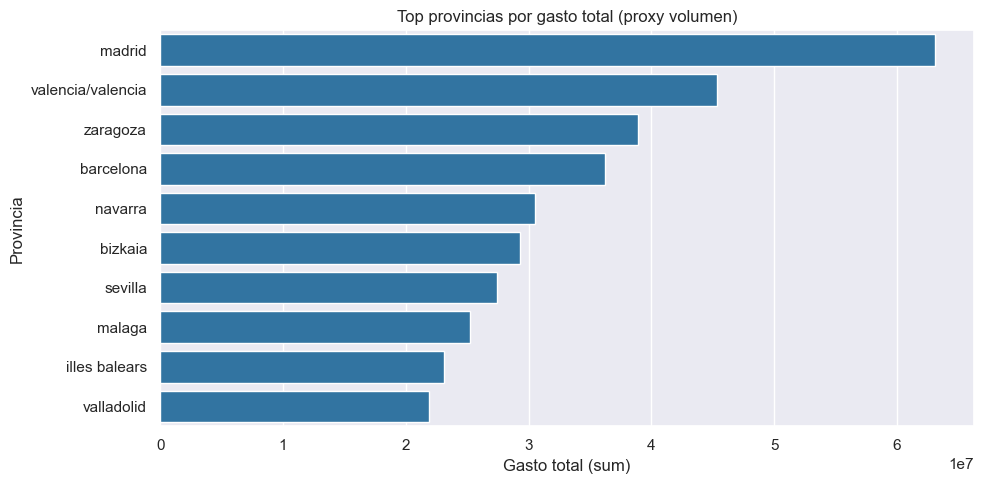

In [13]:
# Top provincias por gasto
plt.figure(figsize=(10,5))
sns.barplot(data=top_prov_gasto, x="gasto_total", y="provincia")
plt.title("Top provincias por gasto total (proxy volumen)")
plt.xlabel("Gasto total (sum)")
plt.ylabel("Provincia")
plt.tight_layout()
plt.show()


En estas provincias se genera un mayor gasto turístico agregado
El análisis del gasto total agregado por provincia permite identificar aquellos territorios donde se concentra una mayor actividad económica asociada al turismo. Provincias como Madrid, Valencia y Barcelona destacan por registrar los niveles más elevados de gasto total, lo que sugiere una alta intensidad turística y una mayor concentración de actividades de ocio y recreativas.

Es importante señalar que este indicador representa un proxy del volumen económico turístico, y no el gasto medio por turista individual. Por tanto, los valores elevados reflejan principalmente una mayor escala de actividad turística en el territorio, más que un mayor nivel de gasto unitari

# Oferta de actividades (densidad / diversidad / perfil destino)

In [14]:
# -----------------------------
# 4) Diversidad por provincia
# -----------------------------
div_prov = (df_actividades.groupby(["comunidad_autonoma","provincia"], as_index=False)
              .agg(
                  num_categorias=("categoria", "nunique"),
                  num_subcategorias=("subcategoria", "nunique"),
                  num_productos=("producto", "nunique"),
                  registros=("categoria", "size")
              ))

display(div_prov.sort_values("num_categorias", ascending=False).head(15))


,comunidad_autonoma,provincia,num_categorias,num_subcategorias,num_productos,registros
0,andalucia,almeria,7,11,2,78
1,andalucia,cadiz,7,10,2,82
6,andalucia,malaga,7,12,2,107
10,aragon,zaragoza,7,11,2,114
5,andalucia,jaen,7,12,2,59
8,aragon,huesca,7,9,2,53
7,andalucia,sevilla,7,11,2,116
16,castilla y leon,leon,7,9,2,44
18,castilla y leon,salamanca,7,11,2,79
11,canarias,las palmas,7,10,2,105


Andalucía presenta una mayor diversidad y cobertura de actividades en el dataset, lo que permite construir itinerarios más variados.
El análisis de diversidad de actividades por provincia muestra que la comunidad autónoma de Andalucía presenta una de las coberturas más amplias y variadas del conjunto de datos. Todas sus provincias incluyen el total de categorías turísticas consideradas y un elevado número de subcategorías, lo que evidencia una oferta turística heterogénea y multifacética.
Esta diversidad permite la construcción de itinerarios personalizados en función de distintos perfiles de viaje, como turismo cultural, gastronómico, urbano, de naturaleza o mixto. En el contexto del proyecto CulturaTrip, Andalucía se identifica como un territorio con alta capacidad para la generación de rutas turísticas adaptables y de alta complejidad.

In [15]:
# -----------------------------
# 4.1) Perfil de destino (categoría dominante por provincia)
# -----------------------------
cat_dom = (df_actividades.groupby(["provincia","categoria"], as_index=False)
             .agg(gasto=("gasto_total_promedio","sum"))
             .sort_values(["provincia","gasto"], ascending=[True, False]))

cat_dom["rank"] = cat_dom.groupby("provincia")["gasto"].rank(method="first", ascending=False)
cat_dom_top = cat_dom[cat_dom["rank"] == 1].drop(columns=["rank"])

display(cat_dom_top.head(20))


,provincia,categoria,gasto
5,a coruna,vida nocturna,4329166.32
10,albacete,vida nocturna,10791419.02
17,alicante/alacant,vida nocturna,5162546.39
24,almeria,vida nocturna,9514030.54
31,araba/alava,vida nocturna,2103936.65
38,asturias,vida nocturna,4382930.88
39,avila,otros,623535.00
47,badajoz,vida nocturna,2479042.77
54,barcelona,vida nocturna,13956706.86
58,bizkaia,paisaje naturaleza,11880233.44


La tabla refleja, para cada provincia, la categoría de actividad que concentra el mayor gasto turístico agregado. Sí se puede inferir que estas son las categorías donde el turista gasta más por provincia, dentro del dataset analizado. La vida nocturna actúa como categoría tractora de gasto en múltiples provincias, especialmente en destinos urbanos y costeros.
El análisis del gasto turístico agregado por provincia permite identificar la categoría de actividad que concentra el mayor volumen económico en cada territorio. Los resultados muestran que, en un número significativo de provincias, la categoría “vida nocturna” actúa como principal generador de gasto, especialmente en destinos urbanos y costeros.
En contraste, en provincias de carácter más rural o natural, el gasto se concentra mayoritariamente en actividades asociadas al paisaje y la naturaleza. Este patrón evidencia la existencia de perfiles territoriales diferenciados de consumo turístico, lo que resulta clave para el diseño de un sistema de recomendación adaptado a distintos tipos de viajeros y motivaciones.

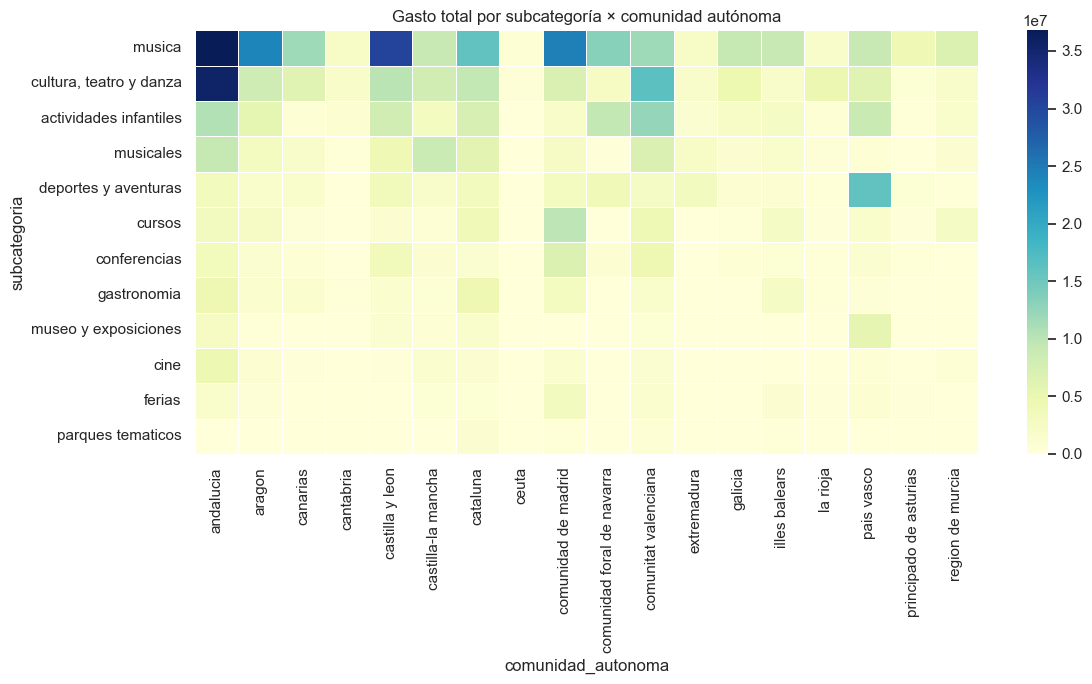

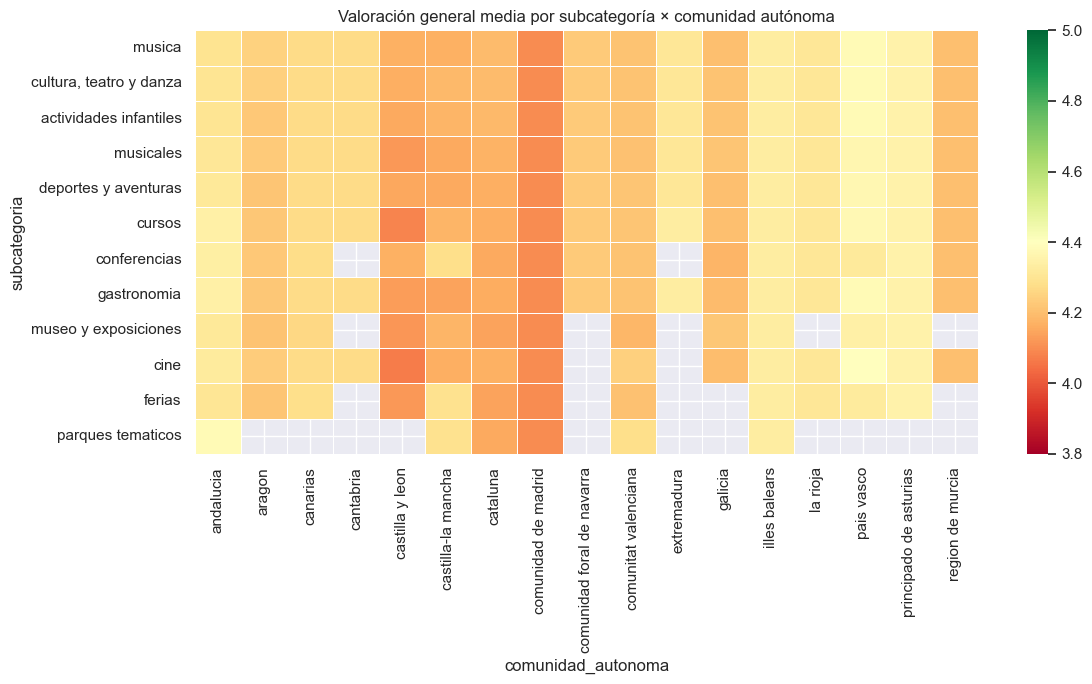

In [16]:
# -----------------------------
# 4.2) Heatmap subcategoría × comunidad (gasto y valoración)
# -----------------------------
pivot_gasto = pd.pivot_table(
    df_actividades, index="subcategoria", columns="comunidad_autonoma",
    values="gasto_total_promedio", aggfunc="sum", fill_value=0
)

pivot_val = pd.pivot_table(
    df_actividades, index="subcategoria", columns="comunidad_autonoma",
    values="valoracion_general_promedio", aggfunc="mean"
)

# Ordenar subcategorías por gasto total global
orden_sub = (df_actividades.groupby("subcategoria")["gasto_total_promedio"].sum()
               .sort_values(ascending=False).index.tolist())
pivot_gasto = pivot_gasto.reindex(orden_sub)
pivot_val   = pivot_val.reindex(orden_sub)

plt.figure(figsize=(12,7))
sns.heatmap(pivot_gasto, cmap=PALETA_HEAT, linewidths=.5)
plt.title("Gasto total por subcategoría × comunidad autónoma")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,7))
sns.heatmap(pivot_val, cmap="RdYlGn", vmin=3.8, vmax=5.0, linewidths=.5)
plt.title("Valoración general media por subcategoría × comunidad autónoma")
plt.tight_layout()
plt.show()


Heatmap de gasto total por subcategoría × CCAA
las que zonas más intensas indican dónde se concentra el gasto turístico por tipo de actividad
El gasto total se interpreta como un proxy de volumen económico turístico asociado a cada subcategoría, permitiendo identificar especializaciones territoriales y áreas de mayor intensidad de consumo turístico

Heatmap de valoración general media por subcategoría × CCAA
Mide la La percepción media de calidad/satisfacción del turista.
La valoración media permite introducir una dimensión cualitativa en el análisis, evidenciando que el volumen económico no siempre se traduce en mayor satisfacción percibida

El análisis conjunto del gasto total y de las valoraciones medias por subcategoría y comunidad autónoma permite identificar patrones de especialización turística, así como diferencias relevantes entre volumen económico y percepción de calidad. Los resultados evidencian que los territorios con mayor gasto no siempre presentan las mejores valoraciones, lo que refuerza la necesidad de un sistema de recomendación que combine variables económicas y cualitativas. Este enfoque resulta clave para el diseño de itinerarios personalizados y para la estimación de escenarios de ahorro dentro de la plataforma CulturaTrip.

# Coste vs valoración (calidad–precio)

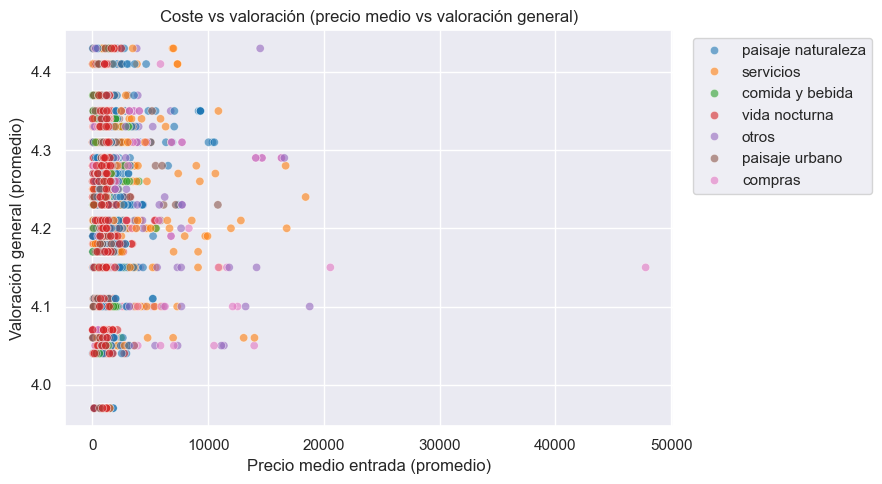

Correlación (precio vs valoración): -0.032


In [17]:
# -----------------------------
# 5) Relación coste vs valoración
# -----------------------------
df_tmp = df_actividades.dropna(subset=["precio_medio_entrada_promedio","valoracion_general_promedio"])

plt.figure(figsize=(9,5))
sns.scatterplot(
    data=df_tmp,
    x="precio_medio_entrada_promedio",
    y="valoracion_general_promedio",
    hue="categoria",
    alpha=0.6
)
plt.title("Coste vs valoración (precio medio vs valoración general)")
plt.xlabel("Precio medio entrada (promedio)")
plt.ylabel("Valoración general (promedio)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

corr = df_tmp[["precio_medio_entrada_promedio","valoracion_general_promedio"]].corr().iloc[0,1]
print("Correlación (precio vs valoración):", round(corr, 3))


Eje X: precio_medio_entrada_promedio
Eje Y: valoracion_general_promedio
Color: categoría de actividad
Correlación: −0.032

No existe relación significativa entre el precio medio y la valoración general. Esto quiere decir que las actividades baratas pueden estar muy bien valoradas y las actividades caras no garantizan mejor experiencia

El análisis de la relación entre el precio medio de entrada y la valoración general muestra una correlación prácticamente nula (−0.032), lo que indica que el coste económico de una actividad no constituye un buen predictor de la percepción de calidad del turista. Este resultado sugiere que existen actividades con elevada satisfacción percibida a precios reducidos, así como experiencias de alto coste cuya valoración no difiere significativamente del promedio. Este hallazgo justifica la necesidad de un sistema de recomendación que combine variables económicas y cualitativas, en lugar de basarse únicamente en el precio.

# Estacionalidad (mes recomendado / temporada)

In [18]:
# -----------------------------
# 6) Estacionalidad general
# -----------------------------
mensual = (df_actividades.groupby("mes", as_index=False)
             .agg(
                 gasto=("gasto_total_promedio","mean"),
                 precio=("precio_medio_entrada_promedio","mean"),
                 valoracion=("valoracion_general_promedio","mean"),
                 opiniones=("total_opiniones_categoria_promedio","mean")
             ))

display(mensual)


,mes,gasto,precio,valoracion,opiniones
0,1,228963.288745,1096.154207,4.234981,37919.742255
1,2,183875.099307,1128.604927,4.236937,39366.660517
2,3,184652.864965,1192.257797,4.241378,36895.886926
3,4,198800.308728,1379.614664,4.244057,37613.008304
4,5,188445.406403,1389.339568,4.238436,36961.573939
5,6,141218.641570,1471.887645,4.235868,38261.945602
6,7,143945.370000,1581.803322,4.238477,36877.213576
7,8,149737.903754,1499.314757,4.240594,36347.990649
8,9,156898.405590,1564.253634,4.244796,35768.443051
9,10,172728.534307,1179.687611,4.239077,35790.679067


El gasto en actividades aumenta en invierno, especialmente en periodos festivos (Navidad, Año Nuevo).
El verano es más caro, aunque no necesariamente genera más gasto total agregado

El análisis temporal revela una marcada estacionalidad en los precios de las actividades, con máximos durante los meses de verano y mínimos en invierno. Sin embargo, el gasto total agregado y el volumen de opiniones alcanzan sus valores más altos en los meses invernales, especialmente en enero, febrero y diciembre. La valoración media se mantiene estable a lo largo del año, lo que indica que la satisfacción del turista no depende del momento temporal. Este resultado permite identificar meses óptimos para la planificación del viaje, maximizando la relación calidad–precio

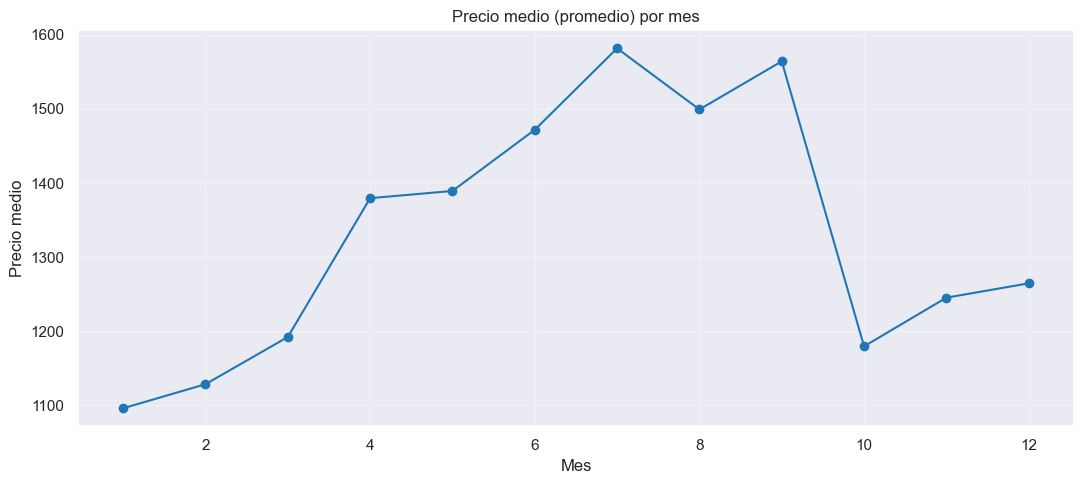

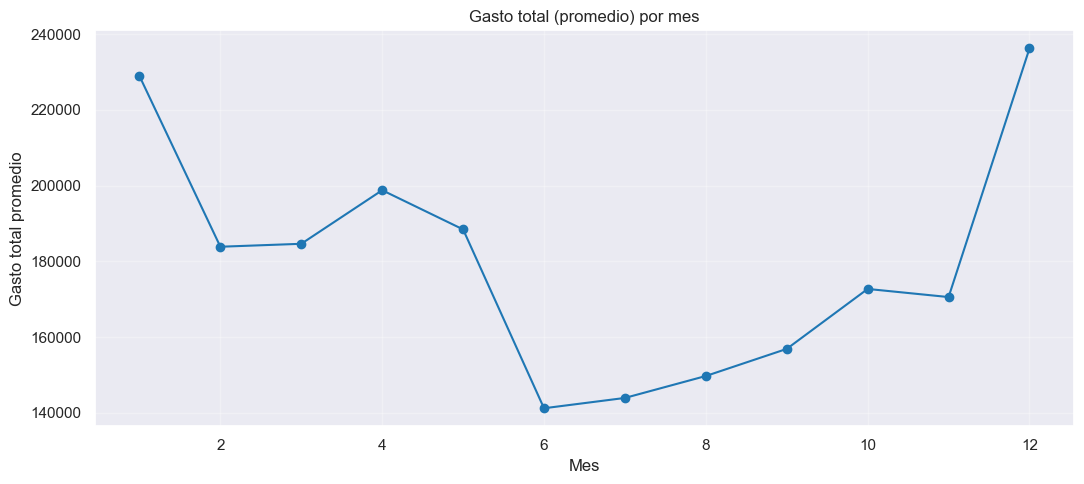

In [19]:
# Series temporales simples
plt.figure()
plt.plot(mensual["mes"], mensual["precio"], marker="o")
plt.title("Precio medio (promedio) por mes")
plt.xlabel("Mes")
plt.ylabel("Precio medio")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(mensual["mes"], mensual["gasto"], marker="o")
plt.title("Gasto total (promedio) por mes")
plt.xlabel("Mes")
plt.ylabel("Gasto total promedio")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


estos gráficos permiten identificar claramente los meses en los que se produce mayor y menor gasto turístico.
El análisis temporal de los precios y del gasto turístico evidencia una marcada estacionalidad en el comportamiento del turista en España. Mientras que los precios medios alcanzan sus máximos durante los meses de verano, el gasto total agregado se concentra especialmente en períodos festivos como Semana Santa y Navidad. Este desacople entre precio y gasto refuerza la necesidad de incorporar variables temporales en el sistema de recomendación, permitiendo estimaciones presupuestarias más realistas y personalizadas según el momento del año.

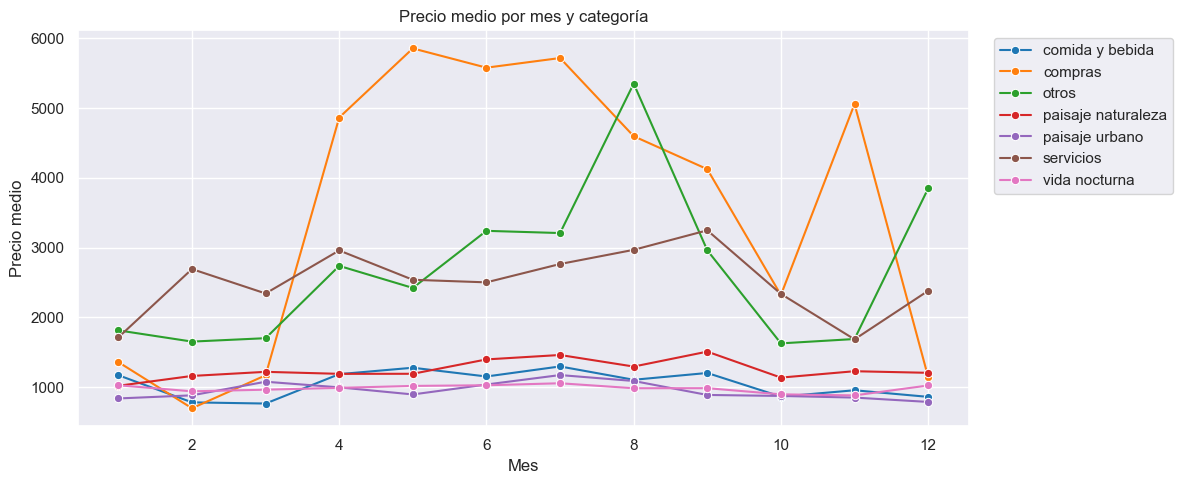

In [20]:
# -----------------------------
# 6.1) Estacionalidad por categoría (precio)
# -----------------------------
mensual_cat = (df_actividades.groupby(["mes","categoria"], as_index=False)
                 .agg(precio=("precio_medio_entrada_promedio","mean"),
                      gasto=("gasto_total_promedio","mean")))

plt.figure(figsize=(12,5))
sns.lineplot(data=mensual_cat, x="mes", y="precio", hue="categoria", marker="o")
plt.title("Precio medio por mes y categoría")
plt.xlabel("Mes")
plt.ylabel("Precio medio")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


este gráfico permite identificar en qué meses se produce un mayor gasto (precio medio) por tipo de actividad.
El análisis del precio medio por mes y categoría evidencia que la estacionalidad impacta de forma desigual según el tipo de actividad turística. Mientras categorías como comida y bebida o vida nocturna presentan una evolución relativamente estable a lo largo del año, otras como compras y actividades especiales muestran picos de gasto muy pronunciados en períodos concretos. Este comportamiento refuerza la necesidad de incorporar la dimensión temporal y tipológica en el sistema de estimación presupuestaria propuesto.

# Escenarios de ahorro (mes/provincia más barata)

In [21]:
# -----------------------------
# 7) Ahorro potencial por mes (robusto con percentiles)
# -----------------------------
def resumen_percentiles(s):
    return pd.Series({
        "p25": s.quantile(0.25),
        "p50": s.quantile(0.50),
        "p75": s.quantile(0.75),
        "mean": s.mean()
    })

ahorro_mes = (
    df_actividades
    .groupby("mes")["precio_medio_entrada_promedio"]
    .apply(resumen_percentiles)
    .unstack()              # 👈 convierte p25/p50/p75/mean en columnas
    .reset_index()
)

ahorro_mes["ahorro_potencial_%"] = (
    (ahorro_mes["p75"] - ahorro_mes["p25"]) / ahorro_mes["p75"] * 100
)

display(ahorro_mes.sort_values("ahorro_potencial_%", ascending=False))




,mes,p25,p50,p75,mean,ahorro_potencial_%
5,6,500.0000,996.000,1617.5000,1471.887645,69.088099
8,9,515.7500,991.250,1644.5000,1564.253634,68.637884
9,10,439.6650,902.750,1365.1000,1179.687611,67.792469
3,4,515.6350,978.350,1484.2000,1379.614664,65.258388
1,2,469.9675,882.585,1299.1250,1128.604927,63.824305
4,5,578.0000,979.485,1533.1675,1389.339568,62.300271
2,3,546.3350,892.000,1390.5450,1192.257797,60.710729
10,11,497.7475,839.970,1246.3825,1245.401382,60.064627
11,12,549.0700,888.500,1354.7500,1264.701498,59.470751
0,1,542.2500,910.500,1313.6500,1096.154207,58.721882


Se logro identificar los meses en los que se ahorra mas.
Qué porcentaje del precio “caro” (p75) puede evitarse si el usuario elige actividades en el rango económico (p25) del mismo mes. El usuario puede reducir entre un 57% y un 69% del coste de actividades si elige opciones optimizadas por el sistema.

El análisis de percentiles del precio medio de actividades por mes permite estimar el potencial de ahorro derivado de la toma de decisiones informada. Los resultados muestran que existe una elevada dispersión de precios durante ciertos meses del año, especialmente en junio, septiembre y octubre, donde el ahorro potencial supera el 65%. Este hallazgo respalda la viabilidad de un sistema de recomendación como CulturaTrip, capaz de guiar al usuario hacia alternativas con una mejor relación calidad-precio sin comprometer la experiencia cultural.

In [22]:
# -----------------------------
# 7.1) Ahorro potencial por provincia (precio)
# -----------------------------
ahorro_prov = (
    df_actividades
    .groupby("provincia")["precio_medio_entrada_promedio"]
    .apply(resumen_percentiles)
    .unstack()              # 👈 convierte p25/p50/p75/mean en columnas
    .reset_index()
)

ahorro_prov["ahorro_potencial_%"] = (
    (ahorro_prov["p75"] - ahorro_prov["p25"]) / ahorro_prov["p75"] * 100
)

display(ahorro_prov.sort_values("ahorro_potencial_%", ascending=False))



,provincia,p25,p50,p75,mean,ahorro_potencial_%
22,guadalajara,267.0000,784.500,1347.0000,894.407838,80.178174
15,ceuta,223.5000,715.000,1067.9150,731.688261,79.071368
5,asturias,595.8000,968.000,2830.2000,2269.941481,78.948484
7,badajoz,189.0000,632.000,894.9650,646.630448,78.881856
18,cuenca,325.0000,910.200,1243.5000,1356.552093,73.864093
32,madrid,657.7700,1145.760,2476.5225,2164.897540,73.439773
39,salamanca,319.3350,642.090,1169.7500,775.280886,72.700577
46,toledo,522.8600,871.780,1886.0000,1215.104923,72.276776
20,girona,382.5200,837.940,1279.7250,1159.204211,70.109203
23,huelva,424.9175,540.700,1392.0000,1038.263529,69.474318


Esta tabla identifica las provincias con mayor margen de variabilidad de precios
demuestra las provincias donde se puede ahorrar mas y se puede hacer varios paquetes de ahorro segun el presupuesto del usuario.
El análisis por percentiles a nivel provincial permite identificar territorios con alta dispersión de precios en actividades turísticas, lo que se traduce en un elevado potencial de optimización del gasto. Estas provincias resultan especialmente adecuadas para la construcción de itinerarios personalizados y paquetes de ahorro, ya que el mismo destino puede adaptarse a distintos perfiles presupuestarios sin comprometer la experiencia turística.

# Cobertura de valoraciones y “confianza” (opiniones)

In [23]:
# -----------------------------
# 8) Cobertura de valoraciones
# -----------------------------
coverage = df_actividades["hay_valoracion"].value_counts(dropna=False).rename_axis("hay_valoracion").reset_index(name="conteo")
display(coverage)

# Nulos por provincia-categoria
nulos_val = (df_actividades.assign(sin_val=np.where(df_actividades["valoracion_general_promedio"].isna(), 1, 0))
               .groupby(["provincia","categoria"], as_index=False)["sin_val"].mean()
               .rename(columns={"sin_val":"prop_sin_valoracion"}))

display(nulos_val.sort_values("prop_sin_valoracion", ascending=False).head(20))


,hay_valoracion,conteo
0,True,3567
1,False,42


,provincia,categoria,prop_sin_valoracion
89,ceuta,vida nocturna,1.0
46,badajoz,servicios,1.0
83,castellon/castello,comida y bebida,1.0
27,araba/alava,otros,1.0
43,badajoz,comida y bebida,1.0
88,ceuta,paisaje urbano,1.0
210,ourense,comida y bebida,1.0
285,zamora,comida y bebida,1.0
3,a coruna,paisaje urbano,0.0
4,a coruna,servicios,0.0


In [24]:
# -----------------------------
# 8.1) Confianza por número de opiniones
# -----------------------------
# Ejemplo de bins (ajusta según distribución real)
df_actividades["opiniones_bin"] = pd.cut(
    df_actividades["total_opiniones_categoria_promedio"],
    bins=[-1, 10, 50, 200, 1000, 1e9],
    labels=["0-10", "11-50", "51-200", "201-1000", "1000+"]
)

val_conf = (
    df_actividades
    .groupby("opiniones_bin", as_index=False, observed=True)
    .agg(
        valoracion=("valoracion_general_promedio", "mean"),
        n=("valoracion_general_promedio", "count")
    )
)

display(val_conf)


,opiniones_bin,valoracion,n
0,0-10,4.191304,46
1,11-50,4.249595,74
2,51-200,4.241749,183
3,201-1000,4.227753,445
4,1000+,4.241493,2819


La cobertura de valoraciones es prácticamente completa, lo que permite utilizar métricas de satisfacción sin necesidad de imputaciones agresivas ni supuestos fuertes.

El análisis de la relación entre número de opiniones y valoración media evidencia una elevada estabilidad en las puntuaciones, lo que sugiere consistencia en la percepción turística. No obstante, el volumen de opiniones se incorpora como un factor de confianza estadística, permitiendo ponderar las recomendaciones sin penalizar destinos con menor visibilidad.

# ¿Qué relación existe entre tipo de producto y gasto promedio?

In [26]:
# Agrupar por producto y calcular métricas promedio
df_producto_gasto = (
    df_actividades
    .groupby("producto", as_index=False)
    .agg(
        gasto_total_promedio=("gasto_total_promedio", "mean"),
        precio_medio_entrada_promedio=("precio_medio_entrada_promedio", "mean"),
        total_registros=("producto", "count")
    )
    .sort_values("gasto_total_promedio", ascending=False)
)

df_producto_gasto


,producto,gasto_total_promedio,precio_medio_entrada_promedio,total_registros
1,espectaculos,211797.444544,1243.688139,2203
0,actividades,127128.309957,1479.069851,1406


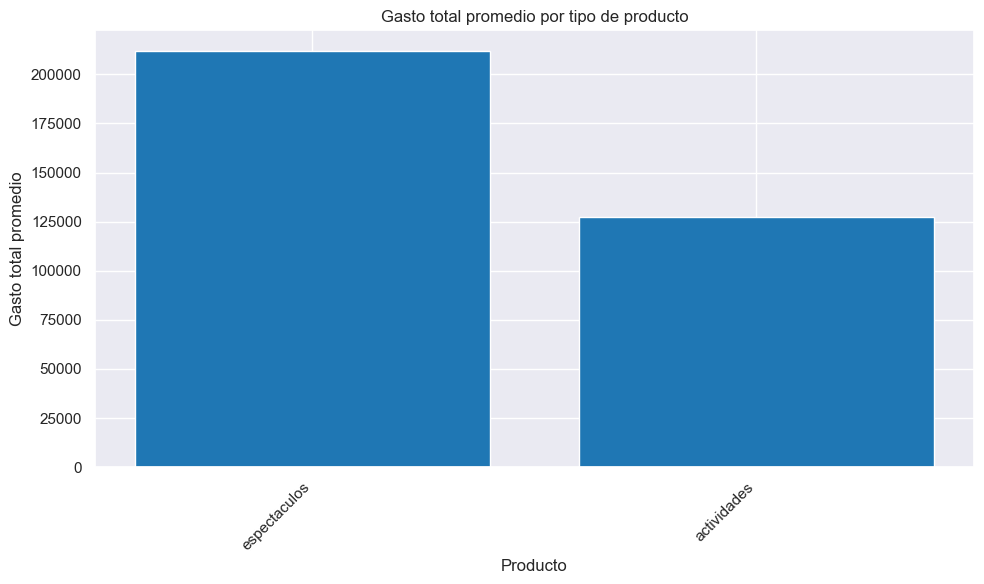

In [27]:
# gasto promedio por tipo de producto (bar chart)
plt.figure(figsize=(10,6))
plt.bar(
    df_producto_gasto["producto"],
    df_producto_gasto["gasto_total_promedio"]
)
plt.title("Gasto total promedio por tipo de producto")
plt.xlabel("Producto")
plt.ylabel("Gasto total promedio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Los espectáculos presentan un gasto total promedio superior al de otras actividades, lo que indica que este tipo de producto implica un mayor desembolso económico por parte del turista.

El análisis muestra que el producto “espectáculos” presenta un gasto total promedio significativamente superior al de “actividades”, lo que sugiere que este tipo de experiencia concentra un mayor nivel de gasto, posiblemente asociado a eventos, entradas con mayor precio o consumo complementario.

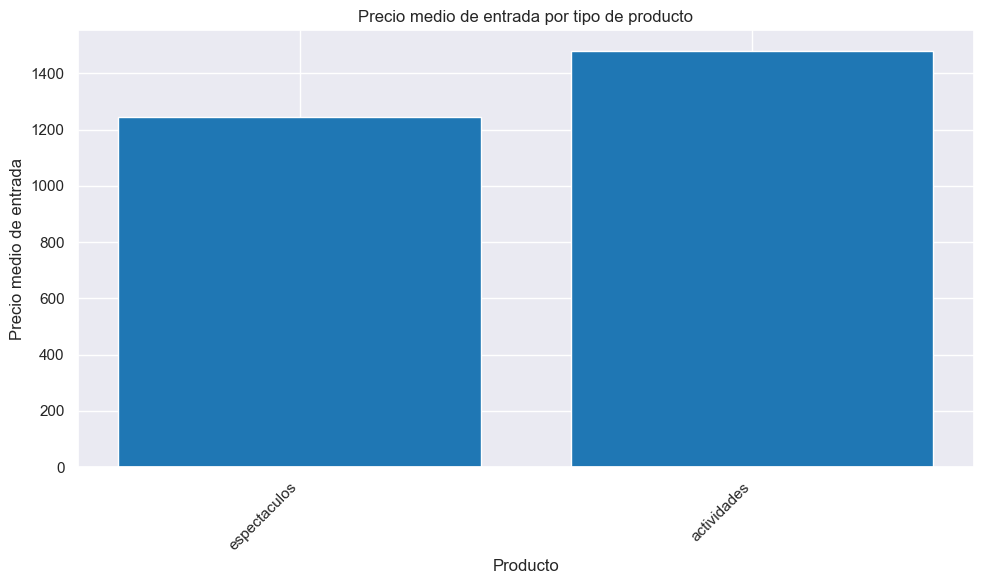

In [28]:
# precio medio de entrada por tipo de producto
plt.figure(figsize=(10,6))
plt.bar(
    df_producto_gasto["producto"],
    df_producto_gasto["precio_medio_entrada_promedio"]
)
plt.title("Precio medio de entrada por tipo de producto")
plt.xlabel("Producto")
plt.ylabel("Precio medio de entrada")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Las actividades presentan un precio medio de entrada superior al de los espectáculos, lo que indica que, cuando existe un acceso mediante entrada, el costo promedio asociado a las actividades es mayor.

El análisis del precio medio de entrada por tipo de producto muestra que las actividades presentan un valor promedio superior al de los espectáculos. Este resultado sugiere que las actividades analizadas suelen implicar un mayor costo de acceso, lo cual puede estar asociado a experiencias que requieren inscripción, ticket o participación guiada.

<Figure size 1200x600 with 0 Axes>

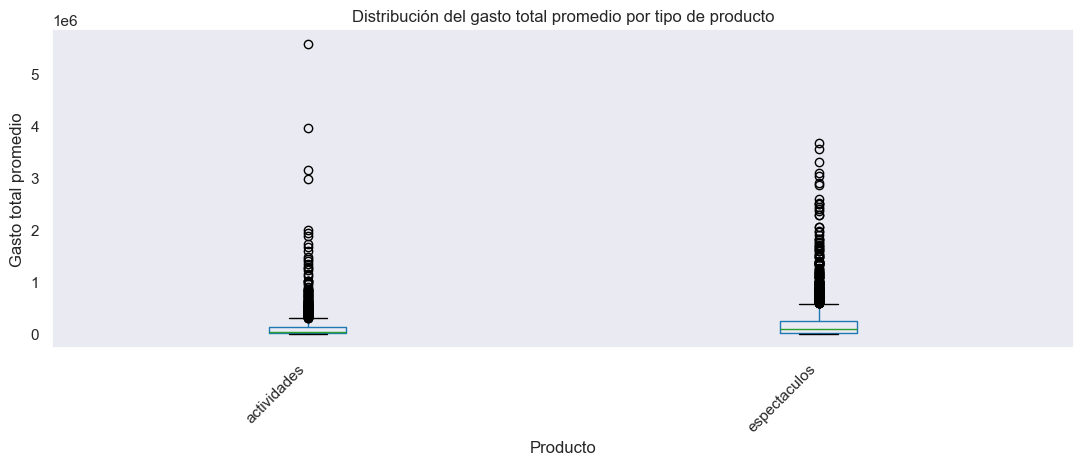

In [30]:
plt.figure(figsize=(12,6))
df_actividades.boxplot(
    column="gasto_total_promedio",
    by="producto",
    grid=False
)
plt.title("Distribución del gasto total promedio por tipo de producto")
plt.suptitle("")
plt.xlabel("Producto")
plt.ylabel("Gasto total promedio")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


La distribución del gasto total promedio por tipo de producto muestra una elevada dispersión en ambos casos, con presencia de valores atípicos. Las actividades presentan una mayor variabilidad y outliers más elevados, lo que indica la existencia de experiencias con gastos significativamente superiores al promedio, mientras que los espectáculos muestran una distribución más concentrada.

In [31]:
df_producto_gasto.style.format({
    "gasto_total_promedio": "{:.2f}",
    "precio_medio_entrada_promedio": "{:.2f}"
})


,producto,gasto_total_promedio,precio_medio_entrada_promedio,total_registros
1,espectaculos,211797.44,1243.69,2203
0,actividades,127128.31,1479.07,1406


El análisis conjunto del gasto total promedio, el precio medio de entrada y el volumen de registros por tipo de producto muestra diferencias claras entre espectáculos y actividades. Los espectáculos presentan un gasto total promedio significativamente mayor, lo que sugiere un mayor desembolso agregado asociado a este tipo de experiencias. Por el contrario, las actividades registran un precio medio de entrada superior, lo que indica que el costo de acceso tiene un mayor peso relativo en este tipo de producto. Asimismo, los espectáculos concentran un mayor número de registros, lo que refleja una mayor presencia de este producto en el conjunto de datos analizado.